Hands-On Lab: Reducing Dimensions with PCA      
● Step 1: Scale a high-dimensional provided dataset with StandardScaler.        
● Step 2: Fit PCA and plot the cumulative explained variance against the number of components.      
● Step 3: Choose the number of components that retains ~95% of the variance and justify it.     
● Step 4: Reduce the data to 2 components and produce a 2D scatter plot, coloring points by a known group if available.         
● Step 5: Document what the reduction preserved and what it cost in Markdown.       

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#### Load & clean data:

In [46]:
df = pd.read_csv("cardiac arrest dataset-selected-columns.csv")

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  target    1025 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 88.2 KB


In [48]:
print(df.head(4))
print("")
print (df.columns)
print("")
print (df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  target
0   52    1   0       125   212    0        1      168      0      1.0       0
1   53    1   0       140   203    1        0      155      1      3.1       0
2   70    1   0       145   174    0        1      125      1      2.6       0
3   61    1   0       148   203    0        1      161      0      0.0       0

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'target'],
      dtype='str')

(1025, 11)


In [49]:
print (df.isna().sum())
print("")
print (df.duplicated().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
target      0
dtype: int64

723


In [50]:
df.drop_duplicates(inplace=True)

print (df.duplicated().sum())



0


#### PCA


Finds new axes — "principal components" — that capture the directions of 
greatest variance in the data.

- The first component captures the most variance.
- The second the next most.(perpendicular to the first), and so..

##### Fit the model

In [51]:
X = df

X_scaled = StandardScaler().fit_transform(X) # scale data

pca = PCA(n_components=2) # instanciate model

X_pca = pca.fit_transform(X_scaled) 

In [52]:
print("Before PCA shape:", X.shape)
print ("After PCA shape:", X_pca.shape)

Before PCA shape: (302, 11)
After PCA shape: (302, 2)


Text(0.5, 1.0, 'PCA princeple Components, 1 = Heart disease,  0 = Normal ')

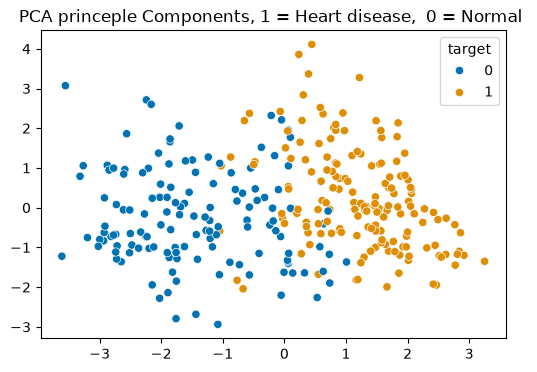

In [77]:
# 2D scatter plot
plt.figure(figsize=(6,4))
ax = sns.scatterplot(x= X_pca[:,0], y= X_pca[:,1], hue=df['target'], palette='colorblind')
ax.set_title('PCA princeple Components, 1 = Heart disease,  0 = Normal ')


##### Explained variance:

How much of the data's total information each component keeps.

- Summing these tells you how much you retained after reduction.

- A common rule: **'keep enough components to retain about 95% of the variance'** .

In [54]:
print(pca.explained_variance_ratio_)          # variance kept per component
print(pca.explained_variance_ratio_.sum())    # total variance retained


[0.24483352 0.14008434]
0.3849178546591392


**To keep 95% variance** :

In [76]:
for i in range(1, len(X.columns)+1):
    
    pca1 = PCA(n_components=i)
    pca1.fit(X_scaled)

    print("Number of components:", i)
    print(pca1.explained_variance_ratio_)        # variance explained by each component
    print(pca1.explained_variance_ratio_.sum()) # total variance retained
    print()

Number of components: 1
[0.24483352]
0.24483351924744312

Number of components: 2
[0.24483352 0.14008434]
0.3849178546591392

Number of components: 3
[0.24483352 0.14008434 0.10868802]
0.49360587724973676

Number of components: 4
[0.24483352 0.14008434 0.10868802 0.09478127]
0.5883871478140037

Number of components: 5
[0.24483352 0.14008434 0.10868802 0.09478127 0.07931312]
0.6677002653287575

Number of components: 6
[0.24483352 0.14008434 0.10868802 0.09478127 0.07931312 0.07554534]
0.743245605360304

Number of components: 7
[0.24483352 0.14008434 0.10868802 0.09478127 0.07931312 0.07554534
 0.06580298]
0.8090485818575833

Number of components: 8
[0.24483352 0.14008434 0.10868802 0.09478127 0.07931312 0.07554534
 0.06580298 0.06257756]
0.8716261391293025

Number of components: 9
[0.24483352 0.14008434 0.10868802 0.09478127 0.07931312 0.07554534
 0.06580298 0.06257756 0.05332379]
0.9249499303287592

Number of components: 10
[0.24483352 0.14008434 0.10868802 0.09478127 0.07931312 0.0755

The closest we can get to retaining ~95% of the variance is when the Number of components: 10 .

Keeping all 11 components would retain 100% of the variance, but it would defeat the purpose of PCA because no dimensionality reduction would be achieved.

By choosing 10 components, we reduce the dataset by one dimension while still retaining 96.41% of the total variance

##### Heatmap:

To visualize(represent) the correlation among principal components(new), and the original features.

In [55]:
print(pca.components_)

[[-0.29031399 -0.13049412  0.33957011 -0.1705753  -0.11073229 -0.04642541
   0.13358042  0.42549511 -0.40615805 -0.37710714  0.48353319]
 [ 0.44193878 -0.37636873  0.27604768  0.47479028  0.40195941  0.29734075
  -0.22346564  0.02898169 -0.19900322  0.02110443  0.14353109]]


In this numpy matrix array:     
 each row represents a principal component,     
  and each column relates back to the original features.

<Axes: >

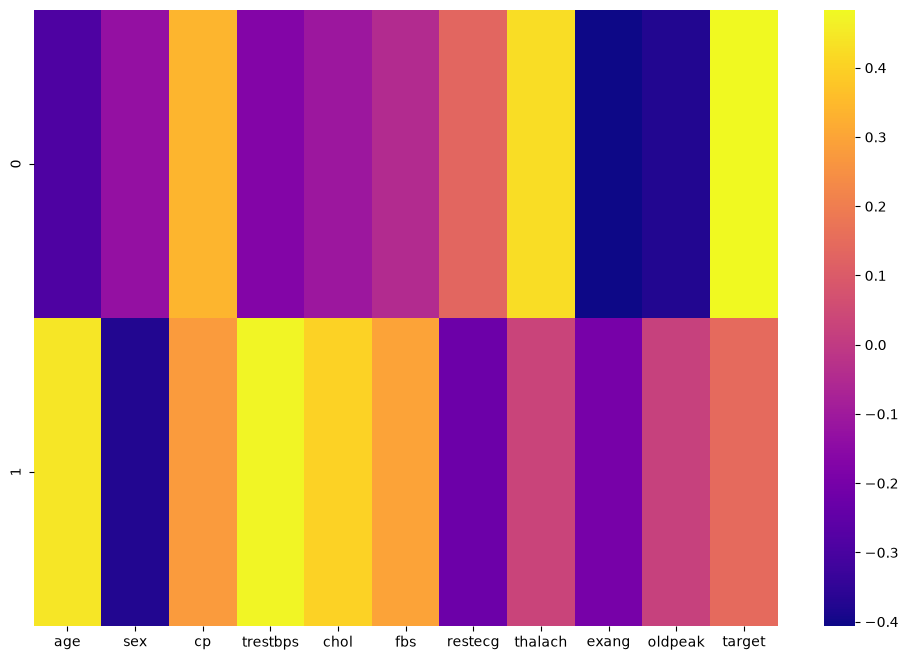

In [56]:
df_components = pd.DataFrame(pca.components_, columns = df.columns)

plt.figure(figsize=(12,8))
sns.heatmap(df_components, cmap='plasma')